# 04.1 Time-Series Model Training

Entrenamiento e inspección reproducible de `PriceSequenceGRU` sobre `data/processed_ts/`.

**Objetivo**
- cargar el dataset secuencial ya validado
- reconstruir el split exacto del checkpoint guardado, si existe
- inspeccionar curvas de entrenamiento, test metrics y threshold tuning
- permitir reentrenar el GRU desde notebook solo si se activa `RUN_TRAINING=True`

**Artefactos esperados**
- `data/models/price_sequence_gru/best_ts_gru_model.pt`
- `data/models/price_sequence_gru/last_ts_gru_model.pt`
- `data/models/price_sequence_gru/training_history.json`
- `data/models/price_sequence_gru/run_config.json`
- `data/models/price_sequence_gru/test_metrics.json`


## 1. Setup

La primera celda carga config, paths y dependencias. Si `data/processed_ts/` no existe, primero hay que correr `python -m src.features.ts_pipeline`.

In [22]:
import sys
import json
import subprocess
import datetime as dt
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from IPython.display import display
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

from src.config import load_config
from src.model.ts_dataset import TimeSeriesMarketDataset, create_ts_train_val_test_dataloaders
from src.model.splits import build_dataset_split
from src.model.ts_architecture import PriceSequenceGRU
from src.model.ts_evaluate import evaluate_ts_model
from src.model.metrics import compute_binary_classification_metrics

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

cfg = load_config(str(ROOT / 'config' / 'config.yaml'))
PROCESSED_TS = ROOT / cfg['ts_data']['processed_dir']
MODELS_DIR = ROOT / cfg['ts_training']['save_dir']
FIGURES = ROOT / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)
RUN_TRAINING = False
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

assert PROCESSED_TS.exists(), f'Dataset TS no encontrado: {PROCESSED_TS}'
print(f'Dataset TS: {PROCESSED_TS}')
print(f'Checkpoint esperado: {MODELS_DIR}')


Dataset TS: /Users/andres/Documents/ITAM/octavo_semestre/mineria_y_analisis/proyecto_polymarket/data/processed_ts
Checkpoint esperado: /Users/andres/Documents/ITAM/octavo_semestre/mineria_y_analisis/proyecto_polymarket/data/models/price_sequence_gru


## 2. Inspección del dataset de entrada

Antes de entrenar conviene revisar metadata y confirmar que el dataset cargado coincide con el notebook 03.1.

In [23]:
dataset = TimeSeriesMarketDataset.from_numpy_dir(str(PROCESSED_TS))
run_config_path = MODELS_DIR / 'run_config.json'
saved_run_config = json.loads(run_config_path.read_text()) if run_config_path.exists() else None
active_split_cfg = (saved_run_config or {}).get('split', {})

n = len(dataset)
print('Metadata dataset TS:')
print(json.dumps(dataset.metadata, indent=2))
print(f'Número de muestras: {n:,}')
print(f'Shape secuencias:   {tuple(dataset.sequences.shape)}')
print(f'Buy rate:           {100 * dataset.labels.mean().item():.1f}%')
print(f'Retención:          {100 * dataset.metadata.get("retention_rate", 0):.1f}%')
if saved_run_config:
    summary = {
        'split_strategy': active_split_cfg.get('strategy'),
        'val_split': active_split_cfg.get('val_split'),
        'test_split': active_split_cfg.get('test_split'),
        'train_size': active_split_cfg.get('train_size'),
        'val_size': active_split_cfg.get('val_size'),
        'test_size': active_split_cfg.get('test_size'),
    }
    print('\nArtefacto guardado detectado:')
    print(json.dumps(summary, indent=2))


Metadata dataset TS:
{
  "num_samples": 19429,
  "seq_len": 64,
  "min_points": 5,
  "num_features": 3,
  "feature_names": [
    "price_yes",
    "delta_price",
    "delta_time_scaled"
  ],
  "snapshot_offset_days": 7,
  "adaptive_cutoff": true,
  "skipped": {
    "no_sequence": 3986,
    "ambiguous": 585,
    "missing_end_date": 0
  },
  "retention_rate": 0.8095416666666667
}
Número de muestras: 19,429
Shape secuencias:   (19429, 64, 3)
Buy rate:           31.9%
Retención:          81.0%

Artefacto guardado detectado:
{
  "split_strategy": "temporal",
  "val_split": 0.15,
  "test_split": 0.15,
  "train_size": 13601,
  "val_size": 2914,
  "test_size": 2914
}


## 3. Split reproducible train / val / test

Igual que en el baseline, el notebook usa el split del `run_config.json` cuando el modelo ya existe.
Así puedes inspeccionar exactamente el mismo GRU que salió de terminal sin reentrenarlo por error.


{
  "strategy": "temporal",
  "seed": 42,
  "val_split": 0.15,
  "test_split": 0.15,
  "train_size": 13601,
  "val_size": 2914,
  "test_size": 2914,
  "temporal_cutoffs": {
    "val_start_timestamp": 1775423700,
    "test_start_timestamp": 1775718000
  },
  "class_balance": {
    "train_positive_rate": 0.3324020206928253,
    "val_positive_rate": 0.3754289746284485,
    "test_positive_rate": 0.2024708241224289
  }
}


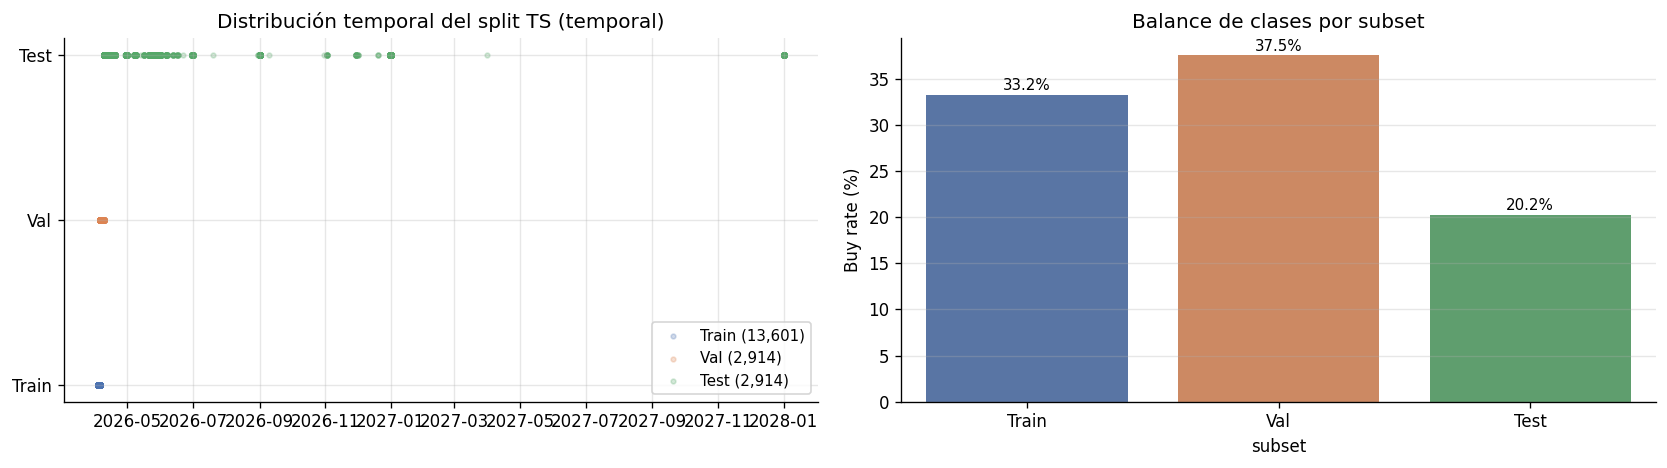

In [24]:
split_cfg = active_split_cfg or {
    'strategy': cfg['ts_training']['split_strategy'],
    'seed': cfg['ts_training']['seed'],
    'val_split': cfg['ts_training']['val_split'],
    'test_split': cfg['ts_training']['test_split'],
}

batch_size = int((saved_run_config or {}).get('batch_size', cfg['ts_training']['batch_size']))
seed = int(split_cfg.get('seed', cfg['ts_training']['seed']))
val_split = float(split_cfg.get('val_split', cfg['ts_training']['val_split']))
test_split = float(split_cfg.get('test_split', cfg['ts_training']['test_split']))
split_strategy = split_cfg.get('strategy', cfg['ts_training']['split_strategy'])

train_loader, val_loader, test_loader, split_metadata = create_ts_train_val_test_dataloaders(
    dataset,
    batch_size=batch_size,
    val_split=val_split,
    test_split=test_split,
    split_strategy=split_strategy,
    use_weighted_sampler=True,
    seed=seed,
)

split = build_dataset_split(
    n_samples=len(dataset),
    labels=dataset.labels.numpy(),
    timestamps=dataset.timestamps,
    val_split=val_split,
    test_split=test_split,
    strategy=split_strategy,
    seed=seed,
)
print(json.dumps(split_metadata, indent=2))

subset_map = {
    'Train': np.array(split.train_indices),
    'Val': np.array(split.val_indices),
    'Test': np.array(split.test_indices),
}
positive_rates = {
    name: float(dataset.labels[idx].float().mean().item())
    for name, idx in subset_map.items()
    if len(idx) > 0
}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax = axes[0]
timestamps = np.asarray(dataset.timestamps)
for name, color in [('Train', PALETTE[0]), ('Val', PALETTE[1]), ('Test', PALETTE[2])]:
    idx = subset_map[name]
    if len(idx) == 0:
        continue
    dates = [dt.datetime.fromtimestamp(ts, tz=dt.timezone.utc) for ts in timestamps[idx]]
    ax.scatter(dates, [name] * len(idx), alpha=0.25, s=8, color=color, label=f'{name} ({len(idx):,})')
ax.set_title(f'Distribución temporal del split TS ({split_strategy})')
ax.legend(fontsize=9)

ax = axes[1]
rate_df = pd.DataFrame({
    'subset': list(positive_rates.keys()),
    'positive_rate': [100 * value for value in positive_rates.values()],
})
sns.barplot(data=rate_df, x='subset', y='positive_rate', hue='subset', palette=PALETTE[:len(rate_df)], legend=False, ax=ax)
ax.set_ylabel('Buy rate (%)')
ax.set_title('Balance de clases por subset')
for i, value in enumerate(rate_df['positive_rate']):
    ax.text(i, value + 0.5, f'{value:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES / 'ts_train_split_overview.png', bbox_inches='tight')
plt.show()


## 4. Arquitectura del modelo

`PriceSequenceGRU` es un clasificador secuencial puro:
- entrada por timestep: `price_yes`, `delta_price`, `delta_time_scaled`
- encoder: GRU unidireccional
- cabeza final: `64 -> 32 -> 1` con `sigmoid`

La idea es que aprenda forma, dirección y ritmo de la trayectoria del precio antes del snapshot.

In [25]:
model = PriceSequenceGRU(
    input_dim=dataset.sequences.shape[-1],
    hidden_dim=cfg['ts_model']['hidden_dim'],
    num_layers=cfg['ts_model']['num_layers'],
    dropout=cfg['ts_model']['dropout'],
    task='classification',
)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'Parámetros totales:     {total_params:,}')
print(f'Parámetros entrenables: {trainable_params:,}')
print(f'Dispositivo:            {DEVICE}')


PriceSequenceGRU(
  (gru): GRU(3, 128, num_layers=2, batch_first=True, dropout=0.3)
  (head): Sequential(
    (0): Linear(in_features=128, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)
Parámetros totales:     154,305
Parámetros entrenables: 154,305
Dispositivo:            cpu


## 5. Entrenamiento o carga de artefactos TS

Por default el notebook carga el GRU ya entrenado desde `data/models/price_sequence_gru/`.
Si activas `RUN_TRAINING=True`, ejecuta el script oficial `src.model.ts_train` para regenerar los artefactos completos.


In [26]:
if RUN_TRAINING:
    cmd = [sys.executable, '-m', 'src.model.ts_train', '--config', str(ROOT / 'config' / 'config.yaml')]
    print('Ejecutando:', ' '.join(cmd))
    subprocess.run(cmd, cwd=ROOT, check=True)
else:
    print(f'RUN_TRAINING={RUN_TRAINING} -> usando artefactos ya guardados en {MODELS_DIR.relative_to(ROOT)}')

history_path = MODELS_DIR / 'training_history.json'
run_config_path = MODELS_DIR / 'run_config.json'
test_metrics_path = MODELS_DIR / 'test_metrics.json'
assert history_path.exists(), f'Falta {history_path}'
assert run_config_path.exists(), f'Falta {run_config_path}'
assert test_metrics_path.exists(), f'Falta {test_metrics_path}'

history = json.loads(history_path.read_text())
run_config = json.loads(run_config_path.read_text())
test_metrics = json.loads(test_metrics_path.read_text())
print('Artefactos cargados:')
print(f'  history:      {history_path.name}')
print(f'  run_config:   {run_config_path.name}')
print(f'  test_metrics: {test_metrics_path.name}')


RUN_TRAINING=False -> usando artefactos ya guardados en data/models/price_sequence_gru
Artefactos cargados:
  history:      training_history.json
  run_config:   run_config.json
  test_metrics: test_metrics.json


## 6. Curvas de aprendizaje

Aquí buscamos tres cosas:
- que la loss de validación no diverja
- que `val_auc` supere claramente el azar
- que `val_pr_auc` no colapse si hay desbalance

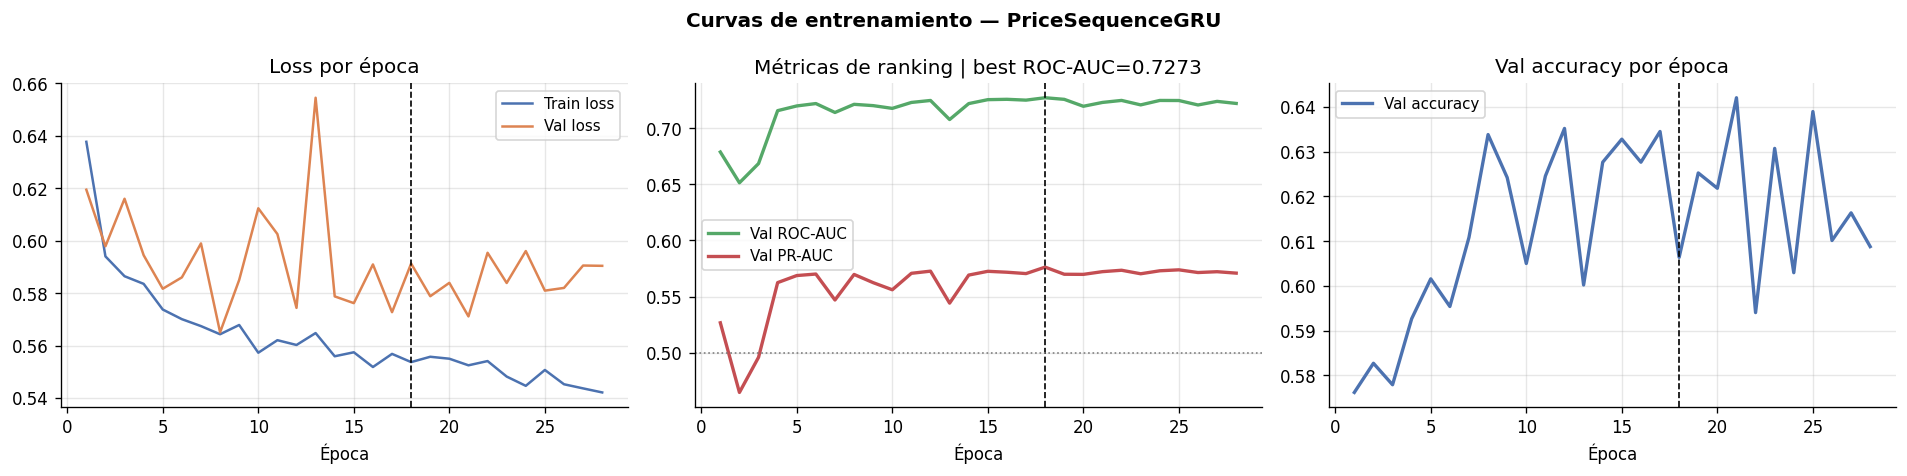

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
epochs_range = range(1, len(history['train_loss']) + 1)
best_epoch = int(history.get('best_epoch', np.argmax(history['val_auc']) + 1))
best_auc = float(history.get('best_val_auc', np.max(history['val_auc'])))

axes[0].plot(epochs_range, history['train_loss'], color=PALETTE[0], label='Train loss')
axes[0].plot(epochs_range, history['val_loss'], color=PALETTE[1], label='Val loss')
axes[0].axvline(best_epoch, color='black', linestyle='--', lw=1)
axes[0].set_title('Loss por época')
axes[0].set_xlabel('Época')
axes[0].legend(fontsize=9)

axes[1].plot(epochs_range, history['val_auc'], color=PALETTE[2], linewidth=2, label='Val ROC-AUC')
axes[1].plot(epochs_range, history['val_pr_auc'], color=PALETTE[3], linewidth=2, label='Val PR-AUC')
axes[1].axvline(best_epoch, color='black', linestyle='--', lw=1)
axes[1].axhline(0.5, color='gray', linestyle=':', lw=1)
axes[1].set_title(f'Métricas de ranking | best ROC-AUC={best_auc:.4f}')
axes[1].set_xlabel('Época')
axes[1].legend(fontsize=9)

axes[2].plot(epochs_range, history['val_accuracy'], color=PALETTE[0], linewidth=2, label='Val accuracy')
axes[2].axvline(best_epoch, color='black', linestyle='--', lw=1)
axes[2].set_title('Val accuracy por época')
axes[2].set_xlabel('Época')
axes[2].legend(fontsize=9)

plt.suptitle('Curvas de entrenamiento — PriceSequenceGRU', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'ts_training_curves.png', bbox_inches='tight')
plt.show()


## 7. Evaluación reproducible en validación y test

El GRU también reporta dos thresholds:
- `0.5`, el default natural de `sigmoid(logit)`
- `threshold_tuned`, elegido en validación para maximizar F1

Si el modelo rankea algo de señal pero el threshold está mal elegido, verás que `ROC-AUC`/`PR-AUC` siguen iguales mientras cambian precision y recall.


In [28]:
best_model = PriceSequenceGRU(
    input_dim=dataset.sequences.shape[-1],
    hidden_dim=cfg['ts_model']['hidden_dim'],
    num_layers=cfg['ts_model']['num_layers'],
    dropout=cfg['ts_model']['dropout'],
    task='classification',
)
best_model.load_state_dict(torch.load(MODELS_DIR / 'best_ts_gru_model.pt', map_location='cpu', weights_only=True))

tuned_threshold = float(test_metrics['threshold_tuning']['threshold'])
val_results_default = evaluate_ts_model(best_model, val_loader, threshold=0.5)
val_results_tuned = evaluate_ts_model(best_model, val_loader, threshold=tuned_threshold)
test_results_default = evaluate_ts_model(best_model, test_loader, threshold=0.5) if test_loader is not None else None
test_results_tuned = evaluate_ts_model(best_model, test_loader, threshold=tuned_threshold) if test_loader is not None else None

rows = []
for split_name, result in [
    ('Val @0.50', val_results_default),
    (f'Val @{tuned_threshold:.3f}', val_results_tuned),
    ('Test @0.50', test_results_default),
    (f'Test @{tuned_threshold:.3f}', test_results_tuned),
]:
    if result is None:
        continue
    rows.append({
        'split': split_name,
        'accuracy': result['accuracy'],
        'precision': result['precision'],
        'recall': result['recall'],
        'f1': result['f1'],
        'auc_roc': result['auc_roc'],
        'pr_auc': result['pr_auc'],
    })

display(pd.DataFrame(rows).round(4))
print('Threshold tuning guardado en disco:')
display(pd.DataFrame([test_metrics['threshold_tuning']]).round(4))


,split,accuracy,precision,recall,f1,auc_roc,pr_auc
0,Val @0.50,0.6064,0.4869,0.9004,0.6320,0.7273,0.5762
1,Val @0.420,0.5889,0.4763,0.9543,0.6354,0.7273,0.5762
2,Test @0.50,0.8010,0.5049,0.8780,0.6411,0.8964,0.6220
3,Test @0.420,0.7865,0.4859,0.9373,0.6400,0.8964,0.6220


Threshold tuning guardado en disco:


,threshold,objective,objective_value,precision_at_threshold,recall_at_threshold
0,0.42,f1,0.6354,0.4763,0.9543


## 8. Threshold tuning sobre validación

Este bloque deja visible el trade-off clásico del GRU: si bajas el threshold ganas recall pero sacrificas precision.


/Users/andres/Documents/ITAM/octavo_semestre/mineria_y_analisis/proyecto_polymarket/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/andres/Documents/ITAM/octavo_semestre/mineria_y_analisis/proyecto_polymarket/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/andres/Documents/ITAM/octavo_semestre/mineria_y_analisis/proyecto_polymarket/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill

,threshold,accuracy,precision,recall,f1,signals
14,0.400,0.5854,0.4743,0.9598,0.6348,2214
15,0.425,0.5879,0.4755,0.9479,0.6333,2181
13,0.375,0.5793,0.4706,0.9653,0.6327,2244
16,0.450,0.5916,0.4776,0.9342,0.6320,2140
18,0.500,0.6064,0.4869,0.9004,0.6320,2023
12,0.350,0.5755,0.4685,0.9707,0.6320,2267
11,0.325,0.5707,0.4658,0.9771,0.6309,2295
17,0.475,0.5961,0.4802,0.9177,0.6305,2091
8,0.250,0.5621,0.4612,0.9899,0.6293,2348
10,0.300,0.5655,0.4629,0.9799,0.6287,2316


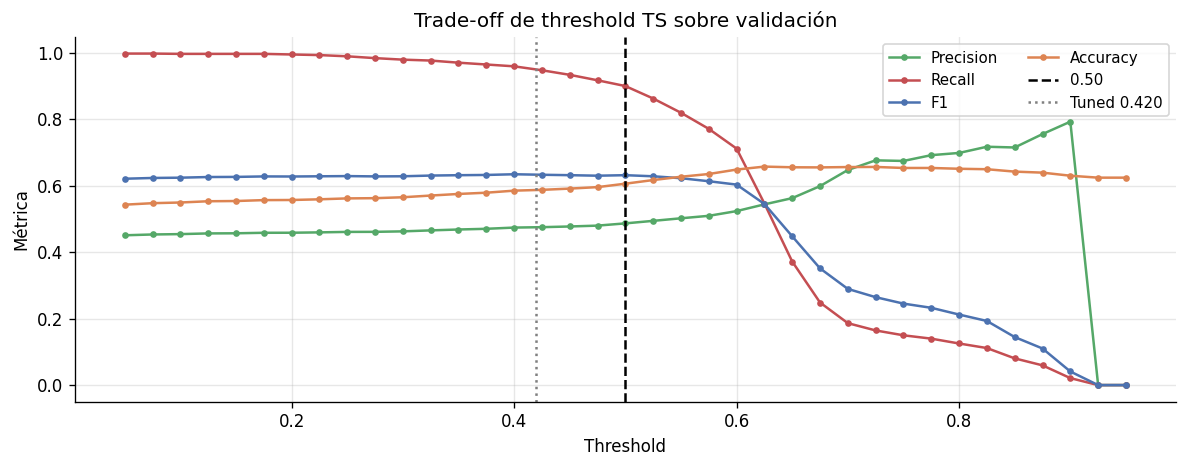

In [29]:
val_labels = val_results_default['labels']
val_scores = val_results_default['scores']
thresholds = np.linspace(0.05, 0.95, 37)
rows = []
for threshold in thresholds:
    metrics = compute_binary_classification_metrics(val_labels, val_scores, threshold=threshold)
    rows.append({
        'threshold': threshold,
        'accuracy': metrics['accuracy'],
        'precision': metrics['precision'],
        'recall': metrics['recall'],
        'f1': metrics['f1'],
        'signals': int(metrics['predictions'].sum()),
    })

df_thresh = pd.DataFrame(rows)
display(df_thresh.sort_values('f1', ascending=False).head(10).round(4))

fig, ax = plt.subplots(figsize=(10, 4))
for metric, color in [('precision', PALETTE[2]), ('recall', PALETTE[3]), ('f1', PALETTE[0]), ('accuracy', PALETTE[1])]:
    ax.plot(df_thresh['threshold'], df_thresh[metric], marker='o', markersize=3, label=metric.capitalize(), color=color)
ax.axvline(0.5, color='black', linestyle='--', lw=1.5, label='0.50')
ax.axvline(tuned_threshold, color='gray', linestyle=':', lw=1.5, label=f'Tuned {tuned_threshold:.3f}')
ax.set_xlabel('Threshold')
ax.set_ylabel('Métrica')
ax.set_title('Trade-off de threshold TS sobre validación')
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES / 'ts_threshold_analysis.png', bbox_inches='tight')
plt.show()


## 9. Diagnóstico visual del modelo

Las gráficas finales ayudan a responder:
- si el umbral `0.5` separa algo útil
- si la ROC realmente está por encima del azar
- si la confusión entre `Buy` y `No Buy` es razonable

/Users/andres/Documents/ITAM/octavo_semestre/mineria_y_analisis/proyecto_polymarket/.venv/lib/python3.11/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


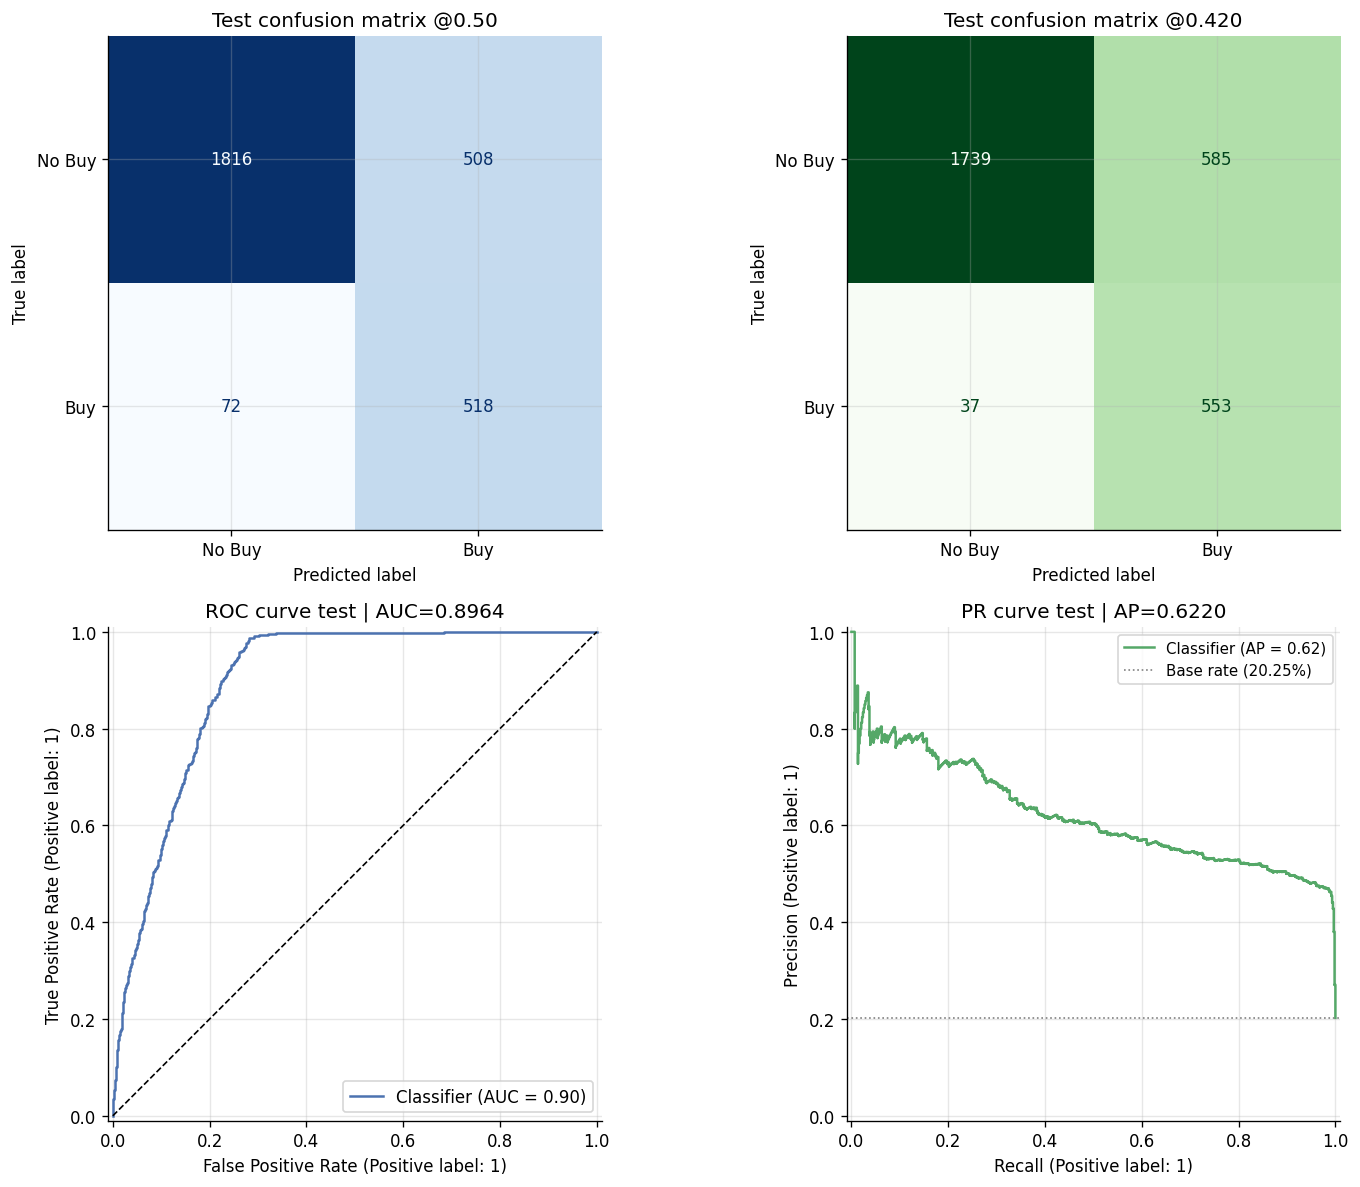

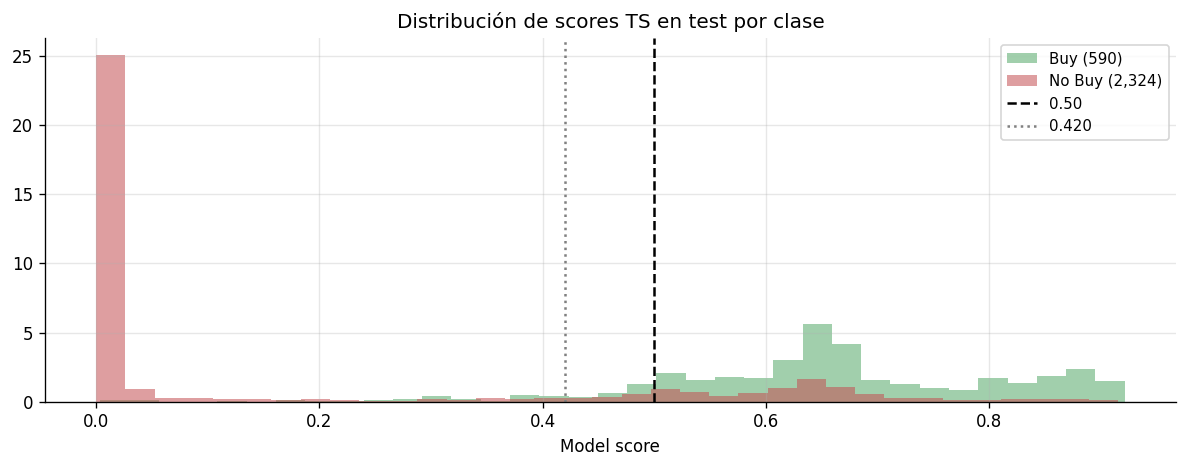

In [30]:
labels_test = test_results_default['labels']
scores_test = test_results_default['scores']

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

ConfusionMatrixDisplay(
    confusion_matrix=test_results_default['confusion_matrix'],
    display_labels=['No Buy', 'Buy'],
).plot(ax=axes[0, 0], colorbar=False, cmap='Blues')
axes[0, 0].set_title('Test confusion matrix @0.50')

ConfusionMatrixDisplay(
    confusion_matrix=test_results_tuned['confusion_matrix'],
    display_labels=['No Buy', 'Buy'],
).plot(ax=axes[0, 1], colorbar=False, cmap='Greens')
axes[0, 1].set_title(f'Test confusion matrix @{tuned_threshold:.3f}')

RocCurveDisplay.from_predictions(labels_test, scores_test, ax=axes[1, 0], color=PALETTE[0])
axes[1, 0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1, 0].set_title(f'ROC curve test | AUC={test_results_default["auc_roc"]:.4f}')

PrecisionRecallDisplay.from_predictions(labels_test, scores_test, ax=axes[1, 1], color=PALETTE[2])
base_rate = float(np.mean(labels_test))
axes[1, 1].axhline(base_rate, color='gray', linestyle=':', lw=1, label=f'Base rate ({base_rate:.2%})')
axes[1, 1].legend(fontsize=9)
axes[1, 1].set_title(f'PR curve test | AP={test_results_default["pr_auc"]:.4f}')

plt.tight_layout()
plt.savefig(FIGURES / 'ts_training_evaluation.png', bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
for label, color, name in [(1, PALETTE[2], 'Buy'), (0, PALETTE[3], 'No Buy')]:
    subset = scores_test[labels_test == label]
    ax.hist(subset, bins=35, alpha=0.55, density=True, color=color, label=f'{name} ({len(subset):,})')
ax.axvline(0.5, color='black', linestyle='--', lw=1.5, label='0.50')
ax.axvline(tuned_threshold, color='gray', linestyle=':', lw=1.5, label=f'{tuned_threshold:.3f}')
ax.set_title('Distribución de scores TS en test por clase')
ax.set_xlabel('Model score')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES / 'ts_test_score_distribution.png', bbox_inches='tight')
plt.show()


## 9.1 Score vs longitud de secuencia

Dado que el GRU usa secuencias de longitud variable (rellenas con padding), vale la pena verificar si la longitud de la secuencia influye en la calidad de predicción.
Una degradación clara en secuencias cortas indicaría que el **adaptive cutoff** introduce ruido.


,len_bucket,n,mean_score,accuracy,buy_rate,seq_len_median
0,Q1\n(cortas),790,0.467,0.661,0.348,8.0
1,Q2,672,0.307,0.774,0.207,17.0
2,Q3\n(largas),1452,0.152,0.890,0.121,64.0


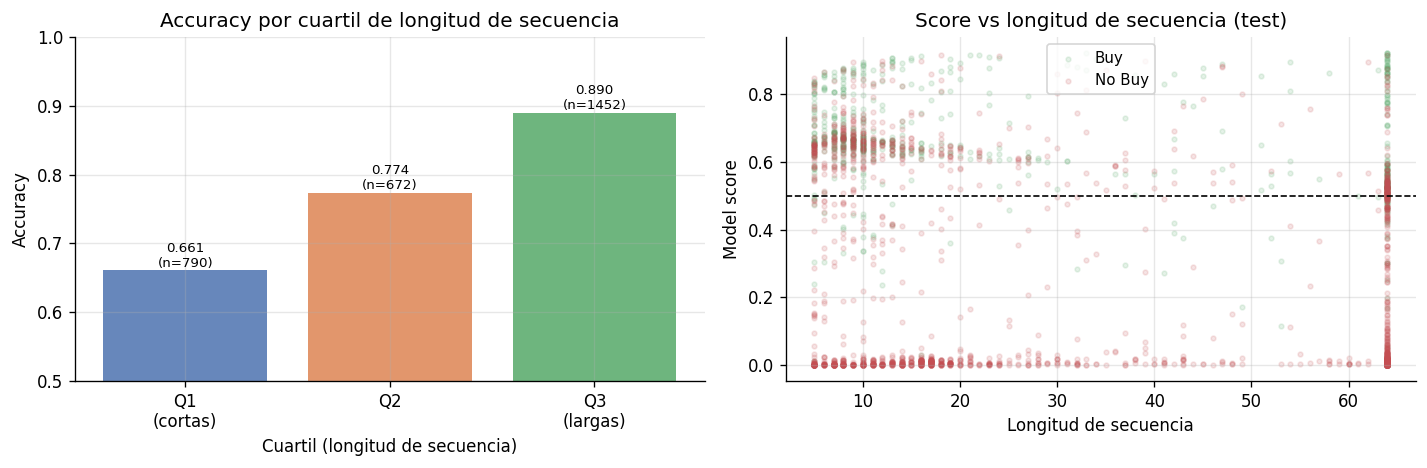

Rango longitudes: 5 – 64 | mediana=41


In [31]:
# Score vs longitud de secuencia en test
test_idx = np.array(split.test_indices)
seq_lengths = dataset.sequence_lengths[test_idx].numpy().astype(int)
labels_arr = np.asarray(labels_test, dtype=int)
scores_arr = np.asarray(scores_test, dtype=float)

df_seq = pd.DataFrame({
    'seq_len': seq_lengths,
    'score':   scores_arr,
    'label':   labels_arr,
    'correct': ((scores_arr >= 0.5).astype(int) == labels_arr),
})

# Cuartiles de longitud — drop duplicates por si muchas secuencias llegan al máximo (64)
buckets, bin_edges = pd.qcut(df_seq['seq_len'], q=4, duplicates='drop', retbins=True)
n_buckets = buckets.nunique()
bucket_labels = [f'Q{i+1}' for i in range(n_buckets)]
bucket_labels[0] += '\n(cortas)'
bucket_labels[-1] += '\n(largas)'
df_seq['len_bucket'] = pd.qcut(df_seq['seq_len'], q=4, duplicates='drop', labels=bucket_labels)

bucket_stats = df_seq.groupby('len_bucket', observed=True).agg(
    n=('score', 'count'),
    mean_score=('score', 'mean'),
    accuracy=('correct', 'mean'),
    buy_rate=('label', 'mean'),
    seq_len_median=('seq_len', 'median'),
).reset_index()
display(bucket_stats.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.bar(bucket_stats['len_bucket'].astype(str), bucket_stats['accuracy'],
       color=PALETTE[:len(bucket_stats)], alpha=0.85)
ax.set_ylim(0.5, 1.0)
ax.set_title('Accuracy por cuartil de longitud de secuencia')
ax.set_xlabel('Cuartil (longitud de secuencia)')
ax.set_ylabel('Accuracy')
for i, row in enumerate(bucket_stats.itertuples()):
    ax.text(i, row.accuracy + 0.005, f'{row.accuracy:.3f}\n(n={row.n})',
            ha='center', fontsize=8)

ax = axes[1]
for label, color, name in [(1, PALETTE[2], 'Buy'), (0, PALETTE[3], 'No Buy')]:
    sub = df_seq[df_seq['label'] == label]
    ax.scatter(sub['seq_len'], sub['score'], alpha=0.15, s=8, color=color, label=name)
ax.axhline(0.5, color='black', linestyle='--', lw=1)
ax.set_title('Score vs longitud de secuencia (test)')
ax.set_xlabel('Longitud de secuencia')
ax.set_ylabel('Model score')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES / 'ts_score_by_seqlen.png', bbox_inches='tight')
plt.show()
print(f'Rango longitudes: {df_seq["seq_len"].min()} – {df_seq["seq_len"].max()} | mediana={df_seq["seq_len"].median():.0f}')


## 10. Siguiente paso

Si el checkpoint quedó guardado y las métricas no se ven degeneradas, ya puedes pasar a:
- `05_1_ts_live_scoring.ipynb` para usar el modelo en activos
- `05_2_model_comparison.ipynb` para compararlo contra `MarketValueNet`